# House Price Prediction


**Santosh Acharya - 22BDS0441**

Tech stack used:-
1. SQL - for storing and retrieving data
2. Python - for data pre-processing and analysis
3. Flask - for web api

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mysql.connector
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pickle

## Importing data with SQL

In [3]:


dataset = pd.read_csv('Data.csv')

In [4]:
print(dataset.iloc[0])

id                                       6.762811e+09
Date                                     4.249100e+04
number of bedrooms                       4.000000e+00
number of bathrooms                      2.500000e+00
living area                              2.920000e+03
lot area                                 4.000000e+03
number of floors                         1.500000e+00
waterfront present                       0.000000e+00
number of views                          0.000000e+00
condition of the house                   5.000000e+00
grade of the house                       8.000000e+00
Area of the house(excluding basement)    1.910000e+03
Area of the basement                     1.010000e+03
Built Year                               1.909000e+03
Renovation Year                          0.000000e+00
Postal Code                              1.220040e+05
Lattitude                                5.288780e+01
Longitude                               -1.144700e+02
living_area_renov           

In [5]:
dataset.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [6]:
dataset.tail()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
14614,6762830250,42734,2,1.5,1556,20000,1.0,0,0,4,...,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14615,6762830339,42734,3,2.0,1680,7000,1.5,0,0,4,...,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14616,6762830618,42734,2,1.0,1070,6120,1.0,0,0,3,...,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14617,6762830709,42734,4,1.0,1030,6621,1.0,0,0,4,...,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000
14618,6762831463,42734,3,1.0,900,4770,1.0,0,0,3,...,1969,2009,122018,52.5338,-114.552,900,3480,2,55,146000


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [8]:
dataset.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,...,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04
mean,6.762821e+09,42604.546412,3.379233,2.129557,2098.156851,1.509369e+04,1.502326,0.007661,0.232848,3.430399,...,1970.929817,90.930228,122033.064300,52.792843,-114.403996,1996.641836,12754.003078,2.012244,64.951433,5.388063e+05
std,6.237162e+03,67.343747,0.938655,0.769955,928.218740,3.792089e+04,0.540241,0.087196,0.765651,0.664047,...,29.491743,416.230218,19.081451,0.137525,0.141325,691.078387,26059.234785,0.817312,8.936129,3.672294e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010500e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.500000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


## Data analysis

<Figure size 1200x800 with 0 Axes>

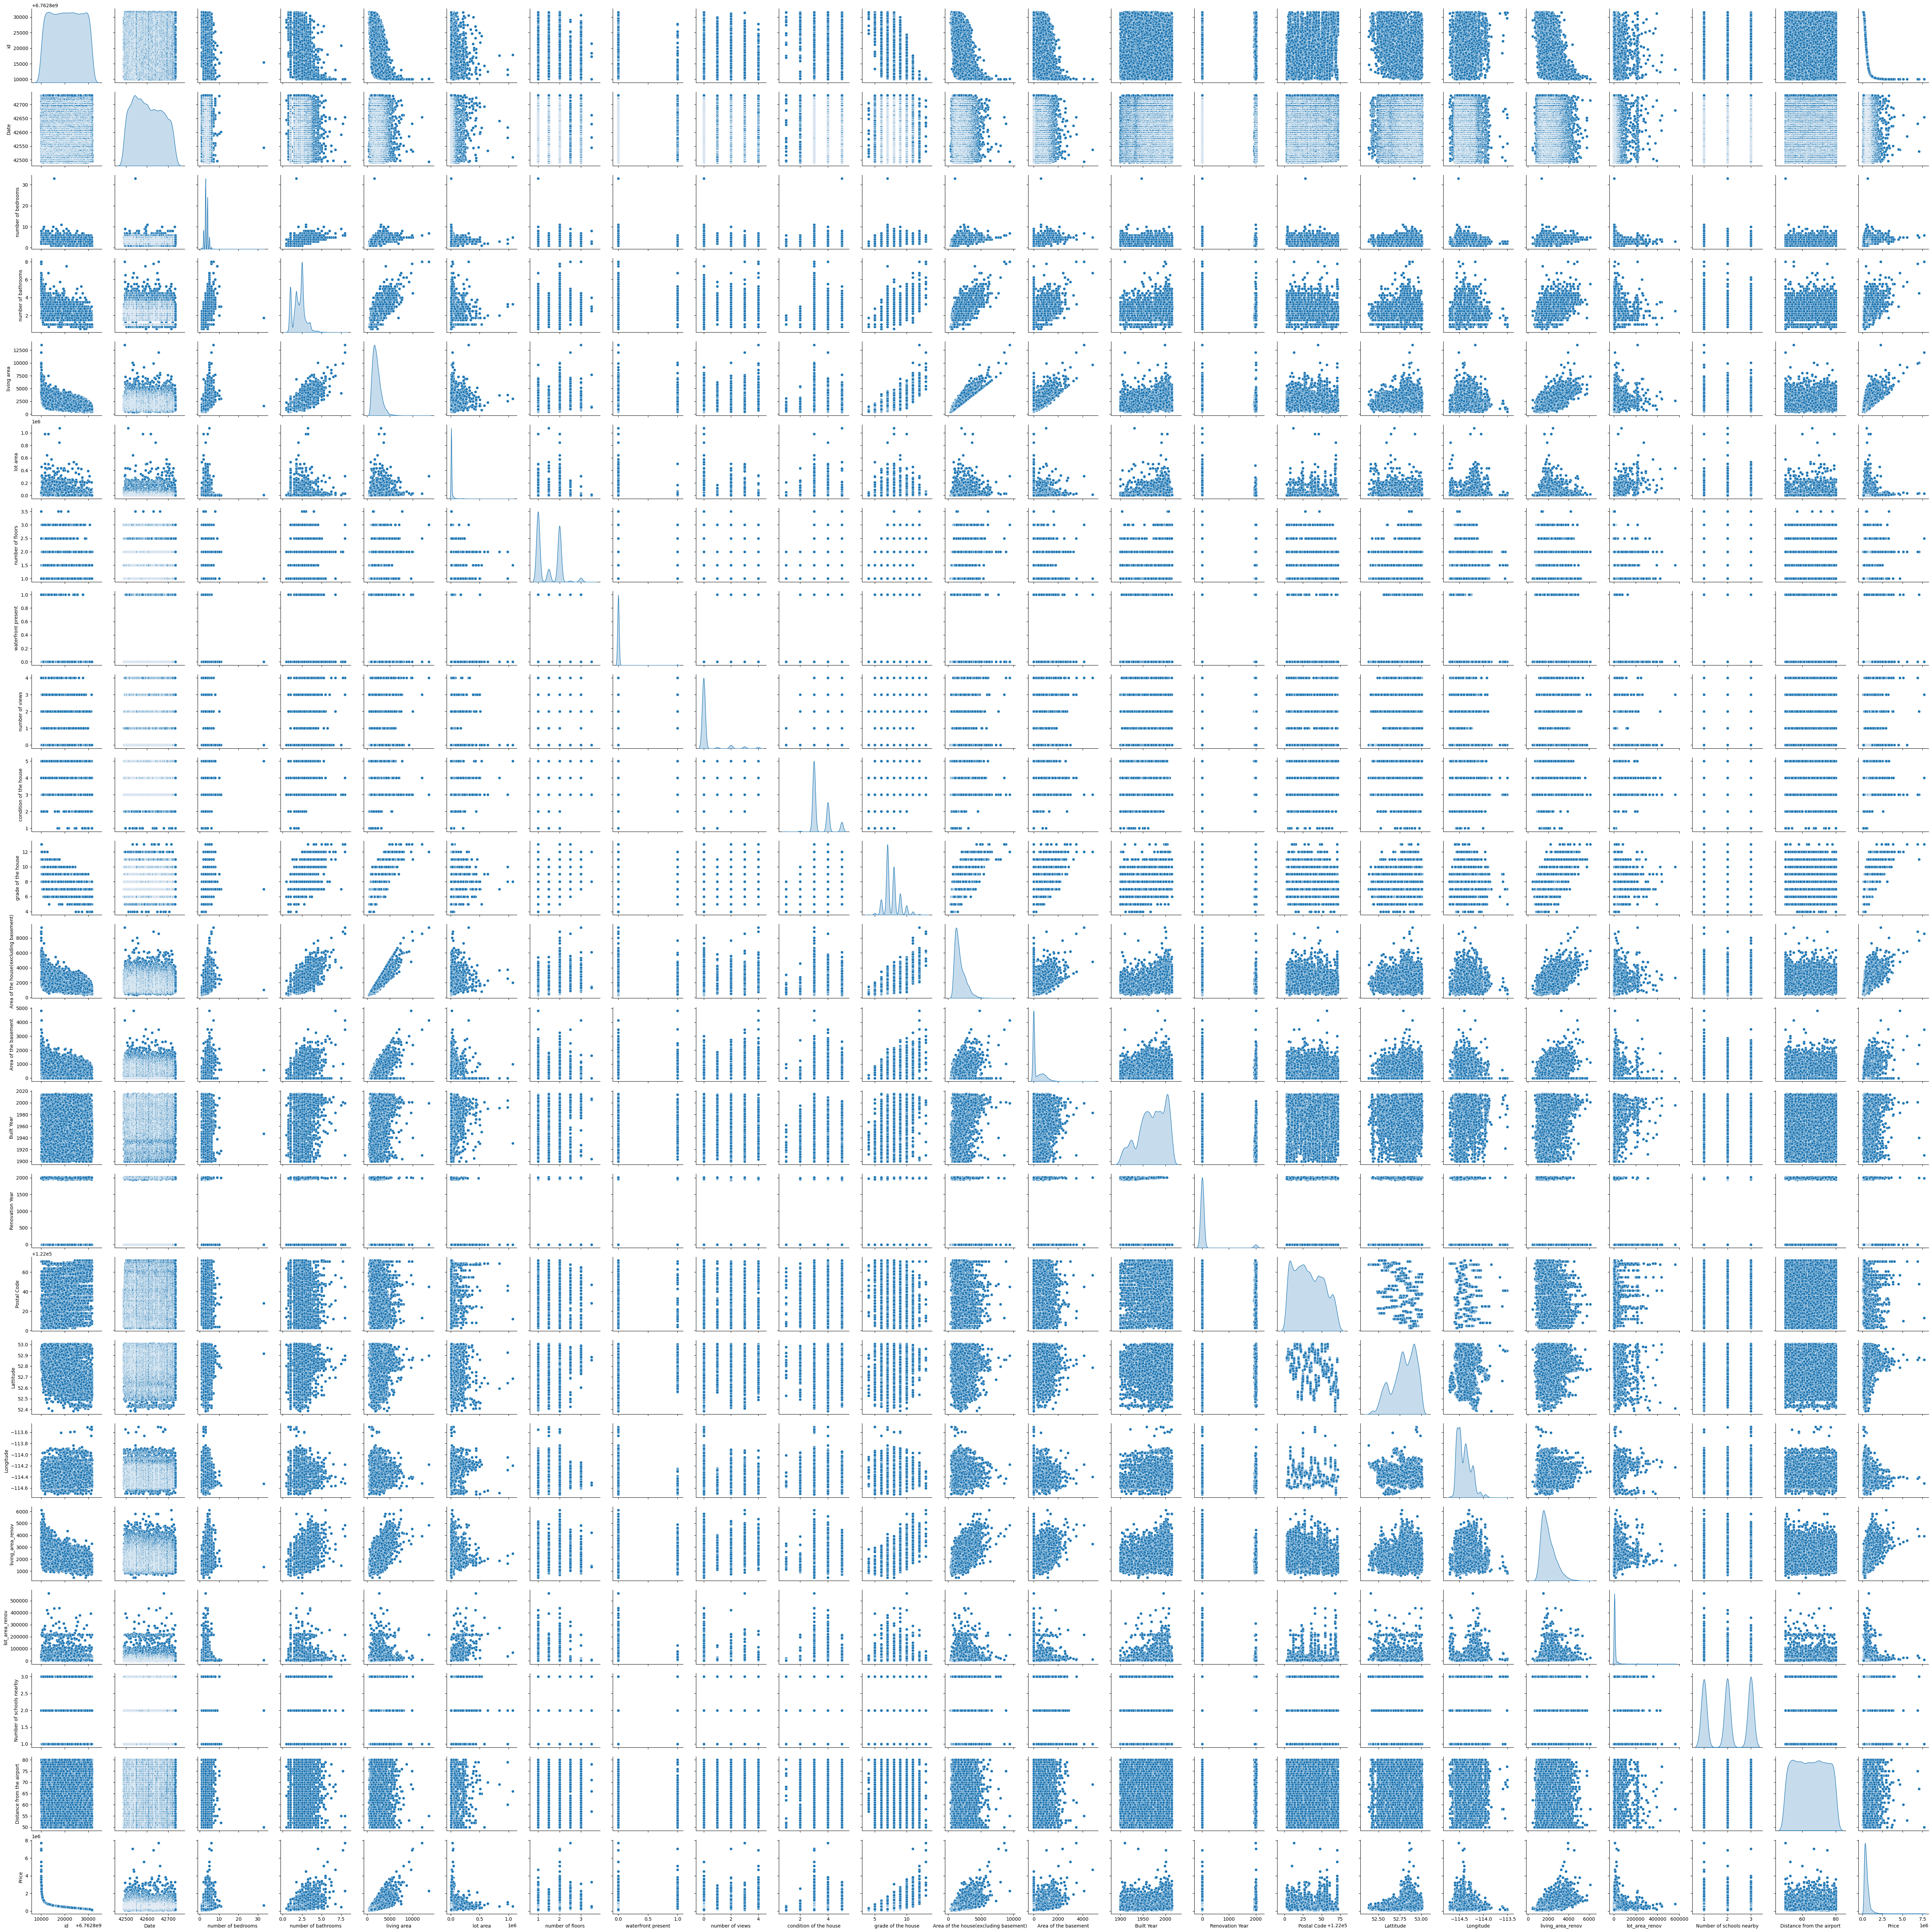

In [9]:
plt.figure(figsize=(12, 8))
sns.pairplot(dataset, diag_kind="kde")
plt.show()

- Renovation_year is not contributing to the price

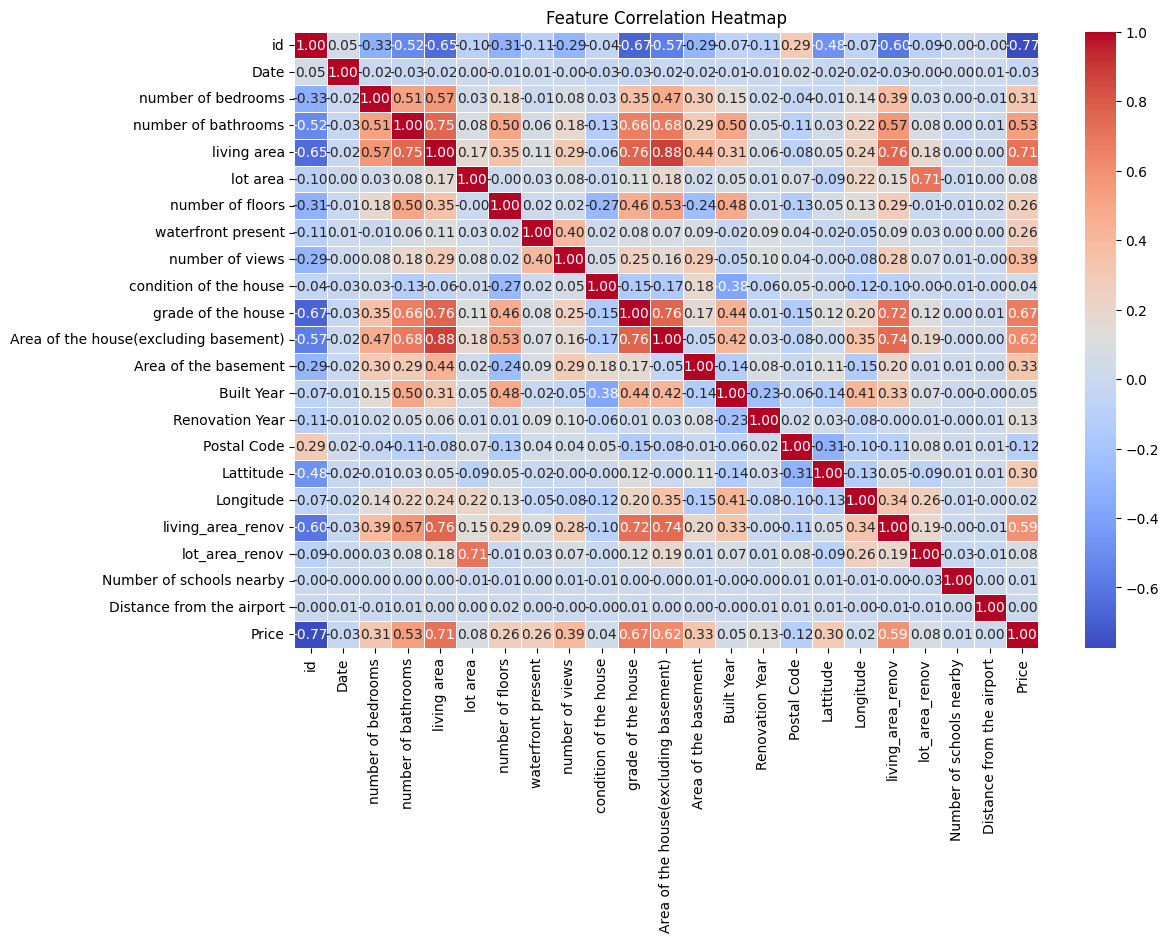

In [10]:
corr_matrix = dataset.corr(method = "pearson")
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Less correlation with price:-
- distance_from_airport (0.00)
- num_schools_nearby (0.01)
- house_condition (0.04)
- built_year (0.05)

Correlation between features:-
- house_area_excluding_basement <-> living_area (0.88)

## Data cleaning

### 1. Dropping columns
1. id
2. Date
3. postal_code
4. distance_from_airport 
5. num_schools_nearby
6. built_year
7. house_condition
8. renovation_year
9. house_area_excluding_basement

In [11]:
dataset.drop(columns=[
    "id", "Date", "Postal Code", "Distance from the airport", "Number of schools nearby",
    "Renovation Year", "Built Year", "condition of the house", "Area of the house(excluding basement)"
], inplace=True)


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number of bedrooms    14619 non-null  int64  
 1   number of bathrooms   14619 non-null  float64
 2   living area           14619 non-null  int64  
 3   lot area              14619 non-null  int64  
 4   number of floors      14619 non-null  float64
 5   waterfront present    14619 non-null  int64  
 6   number of views       14619 non-null  int64  
 7   grade of the house    14619 non-null  int64  
 8   Area of the basement  14619 non-null  int64  
 9   Lattitude             14619 non-null  float64
 10  Longitude             14619 non-null  float64
 11  living_area_renov     14619 non-null  int64  
 12  lot_area_renov        14619 non-null  int64  
 13  Price                 14619 non-null  int64  
dtypes: float64(4), int64(10)
memory usage: 1.6 MB


### 2. Missing values

In [13]:
dataset.isnull().sum()

number of bedrooms      0
number of bathrooms     0
living area             0
lot area                0
number of floors        0
waterfront present      0
number of views         0
grade of the house      0
Area of the basement    0
Lattitude               0
Longitude               0
living_area_renov       0
lot_area_renov          0
Price                   0
dtype: int64

- No missing values

### 3. Datatype validation

- From observations, we can see that the discrete variables (No. of bathrooms and No. of floors) have float values

In [14]:
print(dataset.dtypes[["number of bathrooms", "number of floors"]])

dataset["number of bathrooms"] = dataset["number of bathrooms"].astype(int)
dataset["number of floors"] = dataset["number of floors"].astype(int)

print(dataset.dtypes[["number of bathrooms", "number of floors"]])


number of bathrooms    float64
number of floors       float64
dtype: object
number of bathrooms    int64
number of floors       int64
dtype: object


### 4. Splitting data

In [15]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [16]:
print(X)
print(y)

[[ 4.00000e+00  2.00000e+00  2.92000e+03 ... -1.14470e+02  2.47000e+03
   4.00000e+03]
 [ 5.00000e+00  2.00000e+00  2.91000e+03 ... -1.14468e+02  2.94000e+03
   6.60000e+03]
 [ 4.00000e+00  2.00000e+00  3.31000e+03 ... -1.14321e+02  3.35000e+03
   4.28470e+04]
 ...
 [ 2.00000e+00  1.00000e+00  1.07000e+03 ... -1.14507e+02  1.13000e+03
   6.12000e+03]
 [ 4.00000e+00  1.00000e+00  1.03000e+03 ... -1.14411e+02  1.42000e+03
   6.63100e+03]
 [ 3.00000e+00  1.00000e+00  9.00000e+02 ... -1.14552e+02  9.00000e+02
   3.48000e+03]]
[1400000 1200000  838000 ...  209000  205000  146000]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [18]:
print(X_train)

[[ 5.00000e+00  3.00000e+00  3.57000e+03 ... -1.14197e+02  2.69000e+03
   5.34700e+03]
 [ 4.00000e+00  1.00000e+00  1.45000e+03 ... -1.14537e+02  1.45000e+03
   6.82000e+03]
 [ 4.00000e+00  2.00000e+00  2.78000e+03 ... -1.14232e+02  2.98000e+03
   1.14540e+04]
 ...
 [ 4.00000e+00  2.00000e+00  2.64000e+03 ... -1.14407e+02  2.46000e+03
   4.05700e+03]
 [ 2.00000e+00  1.00000e+00  9.00000e+02 ... -1.14546e+02  9.00000e+02
   5.16000e+03]
 [ 3.00000e+00  2.00000e+00  2.32000e+03 ... -1.14482e+02  2.16000e+03
   5.00000e+03]]


In [19]:
print(y_train)

[627000 375000 715000 ... 436000 219000 900000]


### 4. Feature scaling

In [20]:
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

In [21]:
print(X_train)

[[ 1.79489341  1.67207047  1.57493336 ...  1.46422604  0.997497
  -0.28718556]
 [ 0.69223656 -1.02515217 -0.69370722 ... -0.94518299 -0.79207252
  -0.23066774]
 [ 0.69223656  0.32345915  0.72954371 ...  1.21619864  1.41602536
  -0.05286492]
 ...
 [ 0.69223656  0.32345915  0.57972782 ... -0.02393836  0.66556072
  -0.33668182]
 [-1.51307714 -1.02515217 -1.28226963 ... -1.00896147 -1.58583319
  -0.2943606 ]
 [-0.41042029  0.32345915  0.23729151 ... -0.55542565  0.23260035
  -0.30049967]]


In [22]:
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

In [23]:
print(y_train)

[[ 0.23070281]
 [-0.44069536]
 [ 0.46515931]
 ...
 [-0.27817437]
 [-0.85632279]
 [ 0.95805083]]


### 5. Outliers

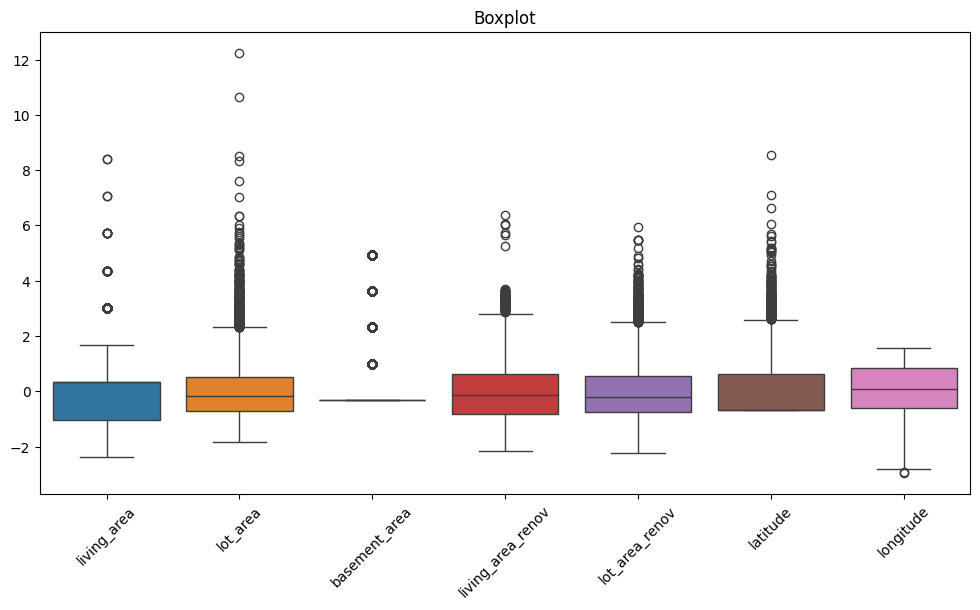

In [26]:
continuous_cols = [
    "living_area", "lot_area", "basement_area", "living_area_renov", "lot_area_renov", "latitude", "longitude"
]

X_train_df = pd.DataFrame(X_train, columns=[
    "num_bathrooms", "living_area", "lot_area", "waterfront_present",
    "num_views", "house_grade", "basement_area", "built_year",
    "latitude", "longitude", "living_area_renov", "lot_area_renov", "distance_from_airport"
])

plt.figure(figsize=(12, 6))
sns.boxplot(data=X_train_df[continuous_cols])
plt.xticks(ticks=range(len(continuous_cols)), labels=continuous_cols, rotation=45)
plt.title("Boxplot")
plt.show()

- Although there are outliers, they are significat factors to predict the price

## Training and testing

In [27]:
def calulate_score(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Mean Absolute Error (MAE):", mae)
    print("Mean Squared Error (MSE):", mse)
    print("R² Score:", r2)

### 1. Multiple Linear Regression

In [28]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = regressor.predict(X_test)
calulate_score(y_test, y_pred)

Mean Absolute Error (MAE): 0.35374353309540824
Mean Squared Error (MSE): 0.2606909548582692
R² Score: 0.6681918931859985


### 2. Decision Tree

In [30]:
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [31]:
y_pred = regressor.predict(X_test)
calulate_score(y_test, y_pred)

Mean Absolute Error (MAE): 0.2609252203925036
Mean Squared Error (MSE): 0.22789562391603474
R² Score: 0.7099338733716846


### 3. Random Forest

In [32]:
regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
regressor.fit(X_train, y_train)

C:\Users\SANTOSH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=0)

In [33]:
y_pred = regressor.predict(X_test)
calulate_score(y_test, y_pred)

Mean Absolute Error (MAE): 0.17906915876227186
Mean Squared Error (MSE): 0.0875377021424509
R² Score: 0.8885817912687995


### 4. XGBoost

In [34]:
regressor = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=0)
regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
y_pred = regressor.predict(X_test)
calulate_score(y_test, y_pred)

Mean Absolute Error (MAE): 0.18182556982432282
Mean Squared Error (MSE): 0.09377108150190268
R² Score: 0.8806479302514979


### 5. Neural network

In [36]:
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer
    Dense(32, activation='relu'),  # Hidden layer
    Dense(16, activation='relu'),  # Hidden layer
    Dense(1)  # Output layer
])

nn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
history = nn_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

C:\Users\SANTOSH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5287 - mae: 0.4332 - val_loss: 0.2543 - val_mae: 0.3061
Epoch 2/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2109 - mae: 0.2751 - val_loss: 0.1916 - val_mae: 0.2651
Epoch 3/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1806 - mae: 0.2462 - val_loss: 0.1905 - val_mae: 0.2588
Epoch 4/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1799 - mae: 0.2339 - val_loss: 0.1441 - val_mae: 0.2290
Epoch 5/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1367 - mae: 0.2146 - val_loss: 0.1594 - val_mae: 0.2360
Epoch 6/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1232 - mae: 0.2066 - val_loss: 0.1498 - val_mae: 0.2293
Epoch 7/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1123 - mae: 0.2041 - val_loss: 0.1607 - val_mae: 0.2282
Epoch 8/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1217 - mae: 0.2073 - val_loss: 0.1247 - val_mae: 0.2141
Epoch 9/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

293/293 [==============================] - 0s 2ms/step - loss: 0.0626 - mae: 0.1661 - val_loss: 0.1586 - val_mae: 0.2112
Epoch 63/100
293/293 [==============================] - 0s 1ms/step - loss: 0.0546 - mae: 0.1589 - val_loss: 0.1577 - val_mae: 0.2124
Epoch 64/100
293/293 [==============================] - 0s 1ms/step - loss: 0.0539 - mae: 0.1585 - val_loss: 0.1674 - val_mae: 0.2152
Epoch 65/100
293/293 [==============================] - 0s 2ms/step - loss: 0.0547 - mae: 0.1592 - val_loss: 0.1736 - val_mae: 0.2136
Epoch 66/100
293/293 [==============================] - 0s 2ms/step - loss: 0.0542 - mae: 0.1594 - val_loss: 0.1677 - val_mae: 0.2164
Epoch 67/100
293/293 [==============================] - 0s 2ms/step - loss: 0.0563 - mae: 0.1606 - val_loss: 0.1508 - val_mae: 0.2096
Epoch 68/100
293/293 [==============================] - 0s 1ms/step - loss: 0.0542 - mae: 0.1589 - val_loss: 0.1688 - val_mae: 0.2168
Epoch 69/100
293/293 [==============================] - 0s 2ms/step - loss:

In [37]:
y_pred = nn_model.predict(X_test)
calulate_score(y_test, y_pred)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error (MAE): 0.20300675521263256
Mean Squared Error (MSE): 0.1162607791739789
R² Score: 0.852022986162249


## Conclusion

Steps performed:-
1. Importing data
2. Data analysis
3. Data cleaning
4. Training
5. Testing

Model trained:-
1. Multiple linear regression - 68%
2. Decision Tree - 77%
3. Random Forest - 88%
4. XGBoost - 89%
5. Neural Network - 87%

- Highest Score is produced by __XGBoost__

## Saving Model

In [38]:
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)

with open("scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)
    
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(regressor, f)